In [33]:
from category_encoders import TargetEncoder 
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

In [4]:
df= pd.read_csv("data/airline_delay_dataset.csv")

In [5]:
df.head

<bound method NDFrame.head of        flight_number    airline origin destination  distance_km  year  month  \
0              AI865  Air India    DEL         BOM         1137  2019      1   
1             6E2131     IndiGo    DEL         BOM         1137  2019      1   
2             QP1102  Akasa Air    DEL         BOM         1137  2019      1   
3              AI506  Air India    DEL         BLR         1740  2019      1   
4             6E2487     IndiGo    DEL         BLR         1740  2019      1   
...              ...        ...    ...         ...          ...   ...    ...   
105845         6E634     IndiGo    CCU         DEL         1305  2023     12   
105846         AI628  Air India    CCU         BOM         1652  2023     12   
105847         6E948     IndiGo    CCU         BLR         1560  2023     12   
105848        6E7307     IndiGo    CCU         HYD         1180  2023     12   
105849        QP1562  Akasa Air    CCU         GOX         1710  2023     12   

        d

In [6]:
df.columns

Index(['flight_number', 'airline', 'origin', 'destination', 'distance_km',
       'year', 'month', 'day_of_week', 'is_weekend', 'dep_hour',
       'temperature_c', 'precip_mm', 'wind_kmh', 'visibility_km', 'storm',
       'snow', 'dep_flights_last_hr', 'arr_flights_last_hr', 'delay_minutes',
       'delay_15'],
      dtype='str')

In [7]:
df.isnull().sum()

flight_number          0
airline                0
origin                 0
destination            0
distance_km            0
year                   0
month                  0
day_of_week            0
is_weekend             0
dep_hour               0
temperature_c          0
precip_mm              0
wind_kmh               0
visibility_km          0
storm                  0
snow                   0
dep_flights_last_hr    0
arr_flights_last_hr    0
delay_minutes          0
delay_15               0
dtype: int64

In [8]:
df["airport_traffic_last_hour"] = df["dep_flights_last_hr"] + df["arr_flights_last_hr"]
df["route"] = df["origin"] + "_" + df["destination"]
df=df.drop(columns=['origin','destination','flight_number', 'dep_flights_last_hr', 'arr_flights_last_hr'  ])

In [9]:
train = df[df['year']<2023]
test = df[df['year']==2023]

In [10]:
X_train= train.drop(columns=['delay_minutes', 'delay_15'])
y_train = train['delay_15']

X_test = test.drop(columns=['delay_minutes', 'delay_15'])
y_test = test['delay_15']

In [11]:
cat_cols= ['airline', 'route',]
te = TargetEncoder(cols=cat_cols)
X_train= te.fit_transform(X_train,y_train)
X_test= te.transform(X_test)

X_train[cat_cols].head()

,airline,route
0,0.634980,0.628109
1,0.578195,0.628109
2,0.586242,0.628109
3,0.634980,0.714807
4,0.578195,0.714807


In [12]:


model = xgb.XGBClassifier(
   
   learning_rate= 0.03,
   max_depth= 5, 
   n_estimators=500,
   objective= 'binary:logistic',
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [13]:
pred= model.predict(X_test)

print(pred)

[0 0 0 ... 1 0 0]


In [14]:
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix,roc_auc_score

print("Accuracy: " ,accuracy_score(y_test,pred))

print("Classification Report: \n", classification_report(y_test,pred))

print("Confusion Matrix: \n", confusion_matrix(y_test,pred))

print("ROC AUC Score: ", roc_auc_score(y_test,pred))

Accuracy:  0.8357805987116332
Classification Report: 
               precision    recall  f1-score   support

           0       0.80      0.79      0.80      8571
           1       0.86      0.87      0.86     12541

    accuracy                           0.84     21112
   macro avg       0.83      0.83      0.83     21112
weighted avg       0.84      0.84      0.84     21112

Confusion Matrix: 
 [[ 6766  1805]
 [ 1662 10879]]
ROC AUC Score:  0.8284404100065728


In [15]:
df["delay_15"].value_counts(normalize=True)

delay_15
1    0.597855
0    0.402145
Name: proportion, dtype: float64

In [16]:
import pandas as pd

imp = pd.Series(model.feature_importances_, index=X_train.columns)
print(imp.sort_values(ascending=False).head(10))

airport_traffic_last_hour    0.439350
storm                        0.203876
precip_mm                    0.157313
snow                         0.063798
airline                      0.040277
visibility_km                0.027693
route                        0.020675
month                        0.011737
day_of_week                  0.006311
distance_km                  0.006132
dtype: float32


In [17]:
import pickle
with open("data/xgb_delay_classifier.pkl", 'wb' ) as f:
    pickle.dump(model, f)

In [21]:
#####################################################
#####################################################
data =df[df['delay_15']==1   ]
print(data.head())
train= data[data['year']<2023]
test= data[data['year']==2023]

     airline  distance_km  year  month  day_of_week  is_weekend  dep_hour  \
0  Air India         1137  2019      1            1           0        11   
1     IndiGo         1137  2019      1            1           0        14   
2  Akasa Air         1137  2019      1            1           0         6   
3  Air India         1740  2019      1            1           0        12   
4     IndiGo         1740  2019      1            1           0        15   

   temperature_c  precip_mm   wind_kmh  visibility_km  storm  snow  \
0      25.104287   0.590289  12.535983       3.978074      0     0   
1      32.994771   4.088217  17.085056       7.144414      0     0   
2      44.669878   0.034994   8.895782       9.645090      0     0   
3      32.329015   0.883705   7.450214       8.342737      1     0   
4      35.273034   2.607764  14.440061       6.207330      0     0   

   delay_minutes  delay_15  airport_traffic_last_hour    route  
0      20.113473         1                         

In [24]:
A_train=train.drop(columns=['delay_minutes', 'delay_15'])
b_train = train['delay_minutes']

A_test= test.drop(columns=['delay_minutes', 'delay_15'])
b_test = test['delay_minutes']

In [25]:
A_train= te.fit_transform(A_train,b_train)
A_test= te.transform(A_test)

In [27]:
model= xgb.XGBRegressor(
    learning_rate= 0.03,
    n_estimators= 500,
    random_state= 42
)

model.fit(A_train, b_train)
pred= model.predict(A_test)

import pickle
with open("data/xgb_delay_regressor.pkl", 'wb' ) as f:
    pickle.dump(model, f)



In [28]:
from sklearn.metrics import mean_squared_error, r2_score    
mse = mean_squared_error(b_test, pred)
r2 = r2_score(b_test, pred)
print("Mean Squared Error: ", mse)
print("R^2 Score: ", r2)        

Mean Squared Error:  8.61093911486334
R^2 Score:  0.6499877291296348


In [30]:
min(pred)

np.float32(15.401944)

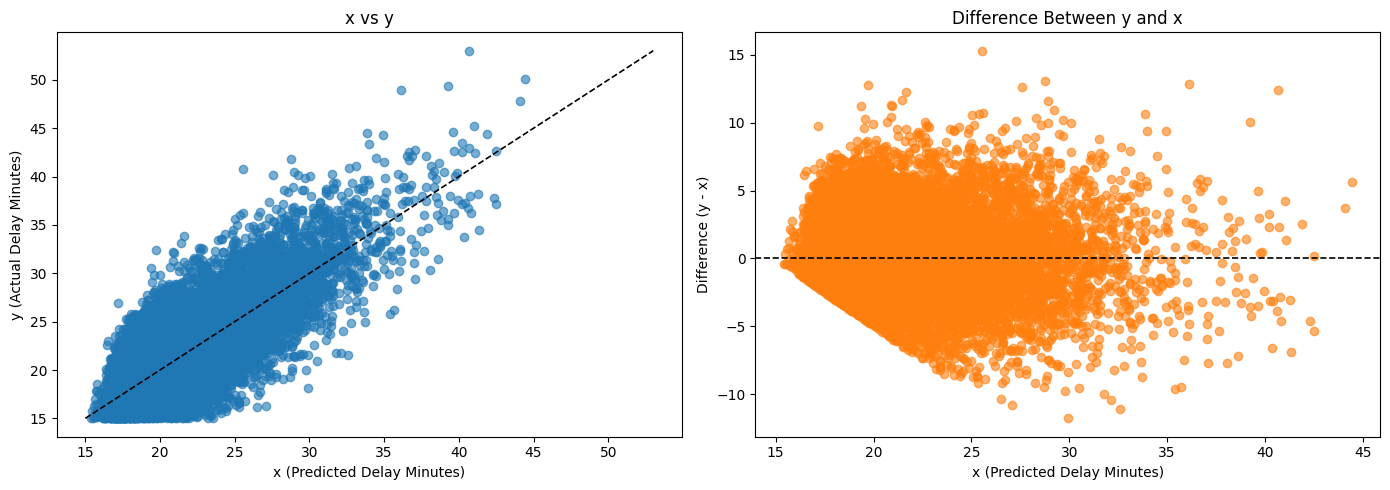

Mean difference (y - x): -0.01
Mean absolute difference: 2.29


In [43]:
x = pd.Series(pred, name="Predicted")
y = b_test.reset_index(drop=True)
diff = y - x  # Positive means actual delay is higher than predicted.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: predicted vs actual with ideal reference line (x = y).
axes[0].scatter(x, y, alpha=0.6, color="tab:blue")
diag_min = min(float(x.min()), float(y.min()))
diag_max = max(float(x.max()), float(y.max()))
axes[0].plot([diag_min, diag_max], [diag_min, diag_max], "k--", linewidth=1.2)
axes[0].set_xlabel("x (Predicted Delay Minutes)")
axes[0].set_ylabel("y (Actual Delay Minutes)")
axes[0].set_title("x vs y")

# Panel 2: residuals to differentiate errors.
axes[1].scatter(x, diff, alpha=0.6, color="tab:orange")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("x (Predicted Delay Minutes)")
axes[1].set_ylabel("Difference (y - x)")
axes[1].set_title("Difference Between y and x")

plt.tight_layout()
plt.show()

print(f"Mean difference (y - x): {diff.mean():.2f}")
print(f"Mean absolute difference: {diff.abs().mean():.2f}")